## Modeling

+ Try different methods for creating text embeddings (Word2Vec, TF-IDF, BERT, etc.)

+ Train catboost classifier on all of them

+ Compare the model with text and numeric features againts the numeric features

+ Calculate the metrics, get the results, and their interpretation

In [26]:
import sys, os
sys.path.insert(0, os.getcwd())   # makes 'vectorizer' importable from modeling/

import json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    explained_variance_score,
)

from vectorizer import preprocess_tokenize, vectorize

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110})

## 1. Load Data

In [27]:
df_raw = pd.read_parquet('../data/data_sample/news_prices_full_processed_with_target_v2.parquet')
print(f'Raw dataset: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}):')
print(list(df_raw.columns))

Raw dataset: (84658, 156)
Columns (156):
['date', 'prev_date', 'future_date', 'title', 'description', 'maintext', 'ticker', 'prev_day_price', 'curr_day_price', 'next_day_price', 'named_entities', 'mentioned_companies', 'related_companies', 'sentiment_negative', 'sentiment_neutral', 'sentiment_positive', 'emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness', 'emotion_disgust', 'emotion_surprise', 'emotion_neutral', 'date_day_of_week', 'prev_day_of_week', 'future_day_of_week', 'language', 'curr_prev_per_change', 'next_curr_per_change', 'curr_prev_pos_change', 'next_curr_pos_change', 'title_word_count', 'description_word_count', 'maintext_word_count', 'title + description + maintext', 'title + description', 'S&P500', 'sector', 'industry', 'marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'long_business_summary', 'weight', 'curr_open', 'curr_high', 'curr_low', 'curr_volume', 'curr_day_range', 'curr_day_gap', 'curr_upper_wick', 'curr_lower_wick', 'close_lag2', 'vol

## 2. Outlier Removal & Sampling

In [28]:
TARGET   = 'next_curr_per_change'
TEXT_COL = 'maintext'  # matches what the user will supply to the agent

print('Target distribution (raw):')
print(df_raw[TARGET].describe(percentiles=[.01, .05, .1, .9, .95, .99]))

q01 = df_raw[TARGET].quantile(0.02)
q99 = df_raw[TARGET].quantile(0.99)
print(f'\nClipping to [{q01:.4f}, {q99:.4f}]')

df = (
    df_raw
    .dropna(subset=[TARGET, 'maintext'])
    .query(f'{q01} <= {TARGET} <= {q99}')
    .reset_index(drop=True)
)
print(f'After outlier removal: {df.shape}')

Target distribution (raw):
count    84658.000000
mean         0.000348
std          0.027513
min         -0.951267
1%          -0.060640
5%          -0.031918
10%         -0.022697
50%          0.000661
90%          0.022022
95%          0.033405
99%          0.066453
max          0.197623
Name: next_curr_per_change, dtype: float64

Clipping to [-0.0468, 0.0665]
After outlier removal: (82133, 156)


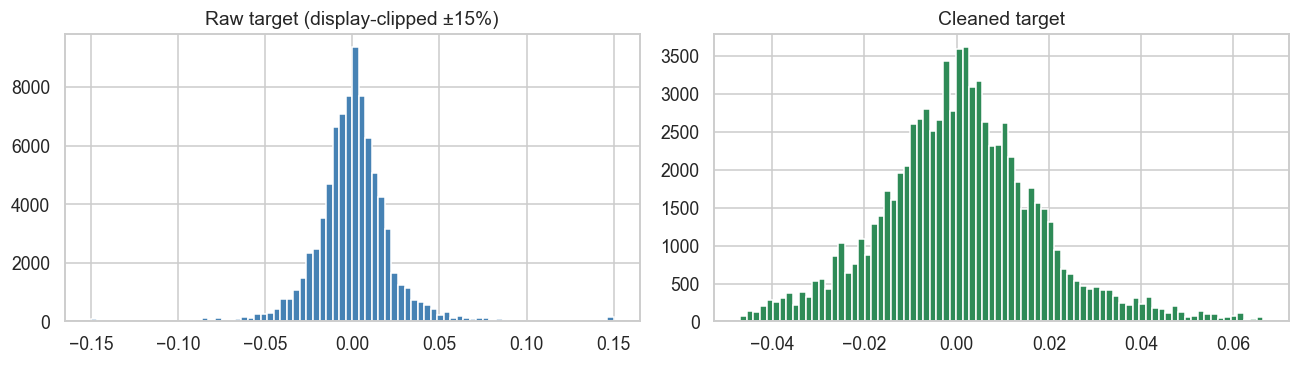

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
df_raw[TARGET].clip(-0.15, 0.15).hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Raw target (display-clipped ±15%)')
df[TARGET].hist(bins=80, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Cleaned target')
plt.tight_layout()
plt.show()

In [30]:
# SAMPLE_FRAC = 0.1
SAMPLE_FRAC = 1 # WE GO THE FULL MODE WE ARE NOT AFRAID OF ANYTHING EXCEPT FOR Jeepers Creepers

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f'Sampled to {SAMPLE_FRAC*100:.0f}%: {df.shape}')
else:
    print(f'Using full dataset: {df.shape}')

Using full dataset: (82133, 156)


## 3. Leakage Prevention

The following columns are **removed before any feature is built**:
- `next_day_price` — this is the numerator of the target; using it is pure leakage  
- `next_curr_pos_change` — binary version of the target  
- `future_date` — a future date that shouldn't be a model input

All lag features in the dataset look *backward* from `date`, so they are safe.  
Current-day OHLCV features assume an **end-of-day prediction window** (article read after market close).

In [31]:
LEAKY_COLS = ['next_day_price', 'next_curr_pos_change', 'future_date']
dropped = [c for c in LEAKY_COLS if c in df.columns]
df = df.drop(columns=dropped)

# Sort chronologically — required for the time-based train/val/test split below
df = df.sort_values('date').reset_index(drop=True)

print(f'Dropped leaky columns: {dropped}')
print(f'Shape after leakage removal: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')

Dropped leaky columns: ['next_day_price', 'next_curr_pos_change', 'future_date']
Shape after leakage removal: (82133, 153)
Date range: 2017-01-04 → 2023-12-27


In [32]:
print(list(df.columns))

['date', 'prev_date', 'title', 'description', 'maintext', 'ticker', 'prev_day_price', 'curr_day_price', 'named_entities', 'mentioned_companies', 'related_companies', 'sentiment_negative', 'sentiment_neutral', 'sentiment_positive', 'emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness', 'emotion_disgust', 'emotion_surprise', 'emotion_neutral', 'date_day_of_week', 'prev_day_of_week', 'future_day_of_week', 'language', 'curr_prev_per_change', 'next_curr_per_change', 'curr_prev_pos_change', 'title_word_count', 'description_word_count', 'maintext_word_count', 'title + description + maintext', 'title + description', 'S&P500', 'sector', 'industry', 'marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'long_business_summary', 'weight', 'curr_open', 'curr_high', 'curr_low', 'curr_volume', 'curr_day_range', 'curr_day_gap', 'curr_upper_wick', 'curr_lower_wick', 'close_lag2', 'volume_lag2', 'sp500_lag2', 'close_lag3', 'volume_lag3', 'sp500_lag3', 'close_lag4', 'volume_lag4', '

## 4. Feature Categories

Every feature group is registered in `FEATURE_CATEGORIES`.  
Add the group key to `EXCLUDE_CATEGORIES` to drop the whole group from the model — useful for ablation studies.

| Key | Contents |
|---|---|
| `sentiment` | Pre-computed negative / neutral / positive scores |
| `emotion` | anger, fear, joy, sadness, disgust, surprise, neutral |
| `text_stats` | Word counts for title, description, maintext |
| `price_momentum` | Current-day return (`curr_prev_per_change`) and direction |
| `curr_ohlcv` | Current-day volume, intraday range, gap, wicks |
| `lag_prices` | Raw close prices at lag 2–28 calendar days |
| `lag_volumes` | Volume at lag 2–28 |
| `sp500_current` | S&P 500 level on the article date |
| `lag_sp500` | S&P 500 at lag 2–28 |
| `lag_returns` | Stock return from lagN to current |
| `lag_directions` | Direction (up/down) of those returns |
| `sp500_returns` | S&P 500 return from lagN to current |
| `sp500_directions` | Direction of S&P 500 returns |
| `volume_changes` | Volume change vs each lag + rolling averages |
| `alpha` | Stock return minus S&P 500 return per lag |
| `momentum` | Differences between returns across horizons |
| `price_range` | Price position within recent high/low range |
| `hist_volatility` | Std of log-returns across lag chain |
| `calendar` | Month, quarter, week, month/quarter-end flags |
| `company_meta` | Marketcap, EBITDA, revenue growth, employees, weight |
| `company_counts` | Number of mentioned / related companies in article |
| `dow` | Day-of-week one-hot (categorical) |
| `ticker` | Ticker one-hot (top-50 + OTHER, categorical) |
| `sector` | Sector one-hot (categorical) |

In [33]:
# ── Compute derived counts from JSON columns ───────────────────────────────────
def count_json_list(s):
    try:
        lst = json.loads(s)
        return len(lst) if isinstance(lst, list) else 0
    except Exception:
        return 0

df['n_mentioned'] = df['mentioned_companies'].apply(count_json_list)
df['n_related']   = df['related_companies'].apply(count_json_list)
print(f"n_mentioned  — mean: {df['n_mentioned'].mean():.2f}, max: {df['n_mentioned'].max()}")
print(f"n_related    — mean: {df['n_related'].mean():.2f}, max: {df['n_related'].max()}")

n_mentioned  — mean: 1.88, max: 12
n_related    — mean: 311.23, max: 3722


In [34]:
LAGS = [2, 3, 4, 5, 7, 14, 21, 28]

# ── Numeric feature groups ─────────────────────────────────────────────────────
FEATURE_CATEGORIES = {
    # NLP pre-computed
    'sentiment':       ['sentiment_negative', 'sentiment_neutral', 'sentiment_positive'],
    'emotion':         ['emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness',
                        'emotion_disgust', 'emotion_surprise', 'emotion_neutral'],
    'text_stats':      ['title_word_count', 'description_word_count', 'maintext_word_count'],
    # Current-day price signals
    'price_momentum':  ['curr_prev_per_change', 'curr_prev_pos_change'],
    'curr_ohlcv':      ['curr_volume', 'curr_day_range', 'curr_day_gap',
                        'curr_upper_wick', 'curr_lower_wick'],
    # Lagged price history
    'lag_prices':      [f'close_lag{l}' for l in LAGS],
    'lag_volumes':     [f'volume_lag{l}' for l in LAGS],
    # S&P 500
    'sp500_current':   ['S&P500'],
    'lag_sp500':       [f'sp500_lag{l}' for l in LAGS],
    # Return / direction signals
    'lag_returns':     [f'ret_lag{l}' for l in LAGS],
    'lag_directions':  [f'dir_lag{l}' for l in LAGS],
    'sp500_returns':   [f'sp500_ret_lag{l}' for l in LAGS],
    'sp500_directions': [f'sp500_dir_lag{l}' for l in LAGS],
    # Volume
    'volume_changes':  ([f'vol_change_lag{l}' for l in LAGS] +
                        ['avg_vol_7d', 'avg_vol_28d', 'rel_vol_7d', 'rel_vol_28d']),
    # Alpha & momentum
    'alpha':           [f'alpha_lag{l}' for l in LAGS],
    'momentum':        ['momentum_2_7', 'momentum_7_28', 'momentum_2_28',
                        'momentum_2_5', 'momentum_5_14',
                        'sp500_momentum_2_7', 'sp500_momentum_7_28', 'sp500_momentum_2_28'],
    # Range & volatility
    'price_range':     ['recent_high_7d', 'recent_low_7d', 'recent_high_28d', 'recent_low_28d',
                        'price_vs_7d_low', 'price_vs_7d_high',
                        'price_vs_28d_low', 'price_vs_28d_high',
                        'price_position_7d', 'price_position_28d'],
    'hist_volatility': ['hist_volatility_approx', 'hist_volatility_7d'],
    # Calendar
    'calendar':        ['month', 'quarter', 'week_of_year',
                        'is_month_start', 'is_month_end', 'is_quarter_end', 'day_of_week_num'],
    # Company metadata
    'company_meta':    ['marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'weight'],
    'company_counts':  ['n_mentioned', 'n_related'],
}

# ── Categorical groups (one-hot encoded) ──────────────────────────────────────
CATEGORICAL_FEATURES = {
    'dow':    'date_day_of_week',   # 5 values
    'ticker': 'ticker',             # top-50 + OTHER
    'sector': 'sector',             # from sp500_companies
}

total = sum(len(v) for v in FEATURE_CATEGORIES.values())
print(f'Total numeric feature slots defined: {total}')
print(f'Categorical groups: {list(CATEGORICAL_FEATURES.keys())}')

Total numeric feature slots defined: 131
Categorical groups: ['dow', 'ticker', 'sector']


In [35]:
# ── CONFIGURE EXCLUSIONS HERE ─────────────────────────────────────────────────
# Add category keys from FEATURE_CATEGORIES or CATEGORICAL_FEATURES to ablate them.
# Example: EXCLUDE_CATEGORIES = ['lag_prices', 'lag_volumes', 'lag_sp500']
EXCLUDE_CATEGORIES = []
# ─────────────────────────────────────────────────────────────────────────────

In [36]:
def build_feature_matrix(df, exclude_categories=None):
    """Build the non-text feature matrix.
    
    Parameters
    ----------
    df : DataFrame — the working dataset (after sampling)
    exclude_categories : list of str — category keys to drop entirely

    Returns
    -------
    X : np.ndarray  shape (n_samples, n_features)
    feature_names : list[str]
    col_to_cat : dict  feature_name -> category_key  (for importance grouping)
    """
    if exclude_categories is None:
        exclude_categories = []

    print(f"\n{'='*58}")
    print(f"  Building feature matrix  "
          f"(excluded: {exclude_categories if exclude_categories else 'none'})")
    print(f"{'='*58}")

    col_to_cat = {}  # tracks which category each final column belongs to

    # ── numeric features ──────────────────────────────────────────────────────
    active_cols = []
    for cat_key, cols in FEATURE_CATEGORIES.items():
        if cat_key in exclude_categories:
            print(f"  SKIP   {cat_key:<22} ({len(cols)} features)")
            continue
        available = [c for c in cols if c in df.columns]
        missing   = [c for c in cols if c not in df.columns]
        status    = 'OK  ' if not missing else 'WARN'
        note      = (f"  ({len(missing)} missing: {missing[:2]}{'...' if len(missing)>2 else ''})" if missing else '')
        print(f"  {status}   {cat_key:<22} {len(available):>3} features{note}")
        for c in available:
            col_to_cat[c] = cat_key
        active_cols.extend(available)

    X_num = df[active_cols].fillna(0).astype(np.float32).values
    feat_names = list(active_cols)

    # ── categorical features (one-hot) ────────────────────────────────────────
    cat_parts = []
    for cat_key, col in CATEGORICAL_FEATURES.items():
        if cat_key in exclude_categories:
            print(f"  SKIP   {cat_key:<22} (categorical)")
            continue
        if col not in df.columns:
            print(f"  MISS   {cat_key:<22} ({col} not in df)")
            continue

        if cat_key == 'ticker':
            top_vals = df[col].value_counts().nlargest(50).index
            series = df[col].where(df[col].isin(top_vals), 'OTHER')
        else:
            series = df[col].fillna('Unknown')

        dummies = pd.get_dummies(series, prefix=cat_key).astype(np.float32)
        print(f"  OK     {cat_key:<22} {dummies.shape[1]:>3} one-hot columns")
        for c in dummies.columns:
            col_to_cat[str(c)] = cat_key
        feat_names.extend(list(dummies.columns.astype(str)))
        cat_parts.append(dummies.values)

    X = np.hstack([X_num] + cat_parts) if cat_parts else X_num
    print(f"\n  → Feature matrix shape: {X.shape}")
    return X, feat_names, col_to_cat


X_features, feature_names, col_to_cat = build_feature_matrix(df, EXCLUDE_CATEGORIES)
print(f'\nFeature names sample: {feature_names[:5]} ... {feature_names[-3:]}')


  Building feature matrix  (excluded: none)
  OK     sentiment                3 features
  OK     emotion                  7 features
  OK     text_stats               3 features
  OK     price_momentum           2 features
  OK     curr_ohlcv               5 features
  OK     lag_prices               8 features
  OK     lag_volumes              8 features
  OK     sp500_current            1 features
  OK     lag_sp500                8 features
  OK     lag_returns              8 features
  OK     lag_directions           8 features
  OK     sp500_returns            8 features
  OK     sp500_directions         8 features
  OK     volume_changes          12 features
  OK     alpha                    8 features
  OK     momentum                 8 features
  OK     price_range             10 features
  OK     hist_volatility          2 features
  OK     calendar                 7 features
  OK     company_meta             5 features
  OK     company_counts           2 features
  OK     d

## 5. Text Preprocessing

In [37]:
texts = df[TEXT_COL].fillna('').astype(str).tolist()
preprocessed, tokenized = preprocess_tokenize(texts)

Preprocessing and tokenizing corpus
Preprocessed 82133 documents


## 6. Shared Split + Helpers

All models use **identical** train / val / test indices — results are directly comparable.

**Split strategy: time-based 60 / 20 / 20.**
The dataset is sorted by date; cutoffs are chosen so that the earliest 60 % of *unique dates* go to train, the next 20 % to val, and the final 20 % to test. This prevents any future information from leaking into training — a random split would allow a 2021-12 article to train on while a 2019-01 article is held out for testing.

In [38]:
y = df[TARGET].values.astype(np.float32)

# ── Time-based 60 / 20 / 20 split ────────────────────────────────────────────
# Cutoffs are computed on unique dates so that articles sharing a date
# always land in the same split (no date straddles a boundary).
unique_dates = np.sort(df['date'].unique())
n_dates      = len(unique_dates)

train_end_date = unique_dates[int(n_dates * 0.91)] # 0.6
val_end_date   = unique_dates[int(n_dates * 0.95)] # 0.8

idx_train = np.where(df['date'] <  train_end_date)[0]
idx_val   = np.where((df['date'] >= train_end_date) & (df['date'] < val_end_date))[0]
idx_test  = np.where(df['date'] >= val_end_date)[0]

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f'Train: {len(idx_train):,}  ({df["date"].iloc[idx_train[0]].date()} → {df["date"].iloc[idx_train[-1]].date()})')
print(f'Val:   {len(idx_val):,}  ({df["date"].iloc[idx_val[0]].date()}  → {df["date"].iloc[idx_val[-1]].date()})')
print(f'Test:  {len(idx_test):,}  ({df["date"].iloc[idx_test[0]].date()}  → {df["date"].iloc[idx_test[-1]].date()})')

results        = []       # one dict per model
trained_models = {}       # method_name -> (model, feature_names, col_to_cat)


def train_catboost(X_tr, y_tr, X_vl, y_vl):
    model = CatBoostRegressor(iterations=3000, early_stopping_rounds=100)
    model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    return model


def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)

    rmse    = float(np.sqrt(mean_squared_error(y_te, y_pred)))
    mae     = float(mean_absolute_error(y_te, y_pred))
    med_ae  = float(np.median(np.abs(y_te - y_pred)))
    max_err = float(np.max(np.abs(y_te - y_pred)))
    r2      = float(r2_score(y_te, y_pred))
    ev      = float(explained_variance_score(y_te, y_pred))

    # Directional accuracy — fraction where predicted sign matches actual sign.
    # Zeros excluded to avoid ambiguity (a zero return has no direction).
    mask    = y_te != 0
    dir_acc = float(np.mean(np.sign(y_pred[mask]) == np.sign(y_te[mask])))

    # Information Coefficient — Spearman rank correlation.
    # Industry-standard signal quality measure; IC > 0.05 is considered useful.
    ic = float(stats.spearmanr(y_pred, y_te).statistic)

    rec = {
        'Method':          name,
        'RMSE':            rmse,
        'MAE':             mae,
        'Median AE':       med_ae,
        'Max Error':       max_err,
        'R²':              r2,
        'Expl. Var.':      ev,
        'Dir. Accuracy':   dir_acc,
        'IC (Spearman)':   ic,
    }

    print(f"\n{'='*50}")
    print(f'  {name}')
    print(f"{'='*50}")
    print(f"  {'RMSE':<18}: {rmse:.6f}")
    print(f"  {'MAE':<18}: {mae:.6f}")
    print(f"  {'Median AE':<18}: {med_ae:.6f}")
    print(f"  {'Max Error':<18}: {max_err:.6f}")
    print(f"  {'R²':<18}: {r2:.6f}")
    print(f"  {'Expl. Var.':<18}: {ev:.6f}  (differs from R² when predictions are biased)")
    print(f"  {'Dir. Accuracy':<18}: {dir_acc:.4f}  ({dir_acc*100:.1f}% correct sign)")
    print(f"  {'IC (Spearman)':<18}: {ic:.4f}  (>0.05 is useful in practice)")
    return rec


def slice_dense(X):
    return X[idx_train], X[idx_val], X[idx_test]

Train: 66,316  (2017-01-04 → 2023-06-29)
Val:   8,958  (2023-06-30  → 2023-09-11)
Test:  6,859  (2023-09-12  → 2023-12-27)


---
## Baseline — Numerical + Categorical Features, No Text

This is the performance ceiling attributable purely to price history, sentiment scores, company metadata, and calendar features — **no text whatsoever**. Every text method below must beat this baseline to justify the extra cost.

In [41]:
X_tr, X_vl, X_te = slice_dense(X_features)
model_base = train_catboost(X_tr, y_train, X_vl, y_val)
res_base   = evaluate(model_base, X_te, y_test, 'Baseline (no text)')
results.append(res_base)
trained_models['Baseline (no text)'] = (model_base, feature_names, col_to_cat)

Learning rate set to 0.050332
0:	learn: 0.0176941	test: 0.0154351	best: 0.0154351 (0)	total: 23.8ms	remaining: 1m 11s
1:	learn: 0.0176159	test: 0.0154443	best: 0.0154351 (0)	total: 36.1ms	remaining: 54.2s
2:	learn: 0.0175611	test: 0.0154342	best: 0.0154342 (2)	total: 49.6ms	remaining: 49.6s
3:	learn: 0.0174866	test: 0.0154322	best: 0.0154322 (3)	total: 59.6ms	remaining: 44.7s
4:	learn: 0.0174338	test: 0.0154183	best: 0.0154183 (4)	total: 68.9ms	remaining: 41.3s
5:	learn: 0.0173559	test: 0.0154253	best: 0.0154183 (4)	total: 80.7ms	remaining: 40.3s
6:	learn: 0.0173026	test: 0.0154060	best: 0.0154060 (6)	total: 92.6ms	remaining: 39.6s
7:	learn: 0.0172514	test: 0.0154018	best: 0.0154018 (7)	total: 105ms	remaining: 39.2s
8:	learn: 0.0171871	test: 0.0154023	best: 0.0154018 (7)	total: 114ms	remaining: 37.9s
9:	learn: 0.0171384	test: 0.0154031	best: 0.0154018 (7)	total: 123ms	remaining: 36.7s
10:	learn: 0.0170923	test: 0.0153995	best: 0.0153995 (10)	total: 136ms	remaining: 37s
11:	learn: 0.017

---
## Method 1 — TF-IDF SVD (300d) + Features

TF-IDF (10k bigrams) → TruncatedSVD to 300 dense dimensions, concatenated with `X_features`.

In [42]:
X_tfidf, tfidf_pipe = vectorize('tf-idf-svd', preprocessed, tokenized)
print(f'TF-IDF SVD embedding shape: {X_tfidf.shape}')

X_tfidf_full = np.hstack([X_tfidf, X_features])
print(f'TF-IDF SVD + features shape: {X_tfidf_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_tfidf_full)
model_tfidf = train_catboost(X_tr, y_train, X_vl, y_val)
res_tfidf   = evaluate(model_tfidf, X_te, y_test, 'TF-IDF SVD + features')
results.append(res_tfidf)

tfidf_names = [f'tfidf_{i}' for i in range(X_tfidf.shape[1])] + feature_names
tfidf_c2c   = {f'tfidf_{i}': 'text_embedding' for i in range(X_tfidf.shape[1])}
tfidf_c2c.update(col_to_cat)
trained_models['TF-IDF SVD + features'] = (model_tfidf, tfidf_names, tfidf_c2c)

Vectorizing using method: tf-idf-svd
Creating TF-IDF matrix with SVD
TF-IDF SVD embedding shape: (82133, 300)
TF-IDF SVD + features shape: (82133, 487)
Learning rate set to 0.050332
0:	learn: 0.0177071	test: 0.0154354	best: 0.0154354 (0)	total: 52.6ms	remaining: 2m 37s
1:	learn: 0.0176419	test: 0.0154083	best: 0.0154083 (1)	total: 76.5ms	remaining: 1m 54s
2:	learn: 0.0175855	test: 0.0154086	best: 0.0154083 (1)	total: 95.3ms	remaining: 1m 35s
3:	learn: 0.0175255	test: 0.0153856	best: 0.0153856 (3)	total: 116ms	remaining: 1m 26s
4:	learn: 0.0174824	test: 0.0153800	best: 0.0153800 (4)	total: 138ms	remaining: 1m 22s
5:	learn: 0.0174389	test: 0.0153749	best: 0.0153749 (5)	total: 160ms	remaining: 1m 19s
6:	learn: 0.0173966	test: 0.0153744	best: 0.0153744 (6)	total: 183ms	remaining: 1m 18s
7:	learn: 0.0173382	test: 0.0153652	best: 0.0153652 (7)	total: 207ms	remaining: 1m 17s
8:	learn: 0.0172578	test: 0.0153774	best: 0.0153652 (7)	total: 229ms	remaining: 1m 16s
9:	learn: 0.0172093	test: 0.0153

---
## Method 2 — Word2Vec (300d) + Features

Skip-gram Word2Vec trained on the corpus. Document vector = mean of in-vocabulary word vectors.

In [43]:
X_w2v, w2v_model = vectorize('word2vec', preprocessed, tokenized)
print(f'Word2Vec embedding shape: {X_w2v.shape}')

X_w2v_full = np.hstack([X_w2v, X_features])
print(f'Word2Vec + features shape: {X_w2v_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_w2v_full)
model_w2v = train_catboost(X_tr, y_train, X_vl, y_val)
res_w2v   = evaluate(model_w2v, X_te, y_test, 'Word2Vec + features')
results.append(res_w2v)

w2v_names = [f'w2v_{i}' for i in range(X_w2v.shape[1])] + feature_names
w2v_c2c   = {f'w2v_{i}': 'text_embedding' for i in range(X_w2v.shape[1])}
w2v_c2c.update(col_to_cat)
trained_models['Word2Vec + features'] = (model_w2v, w2v_names, w2v_c2c)

Vectorizing using method: word2vec
Training Word2Vec model
Word2Vec embedding shape: (82133, 300)
Word2Vec + features shape: (82133, 487)
Learning rate set to 0.050332
0:	learn: 0.0177071	test: 0.0154354	best: 0.0154354 (0)	total: 59.9ms	remaining: 2m 59s
1:	learn: 0.0176347	test: 0.0154414	best: 0.0154354 (0)	total: 84.7ms	remaining: 2m 6s
2:	learn: 0.0175670	test: 0.0154394	best: 0.0154354 (0)	total: 102ms	remaining: 1m 42s
3:	learn: 0.0175055	test: 0.0154201	best: 0.0154201 (3)	total: 127ms	remaining: 1m 35s
4:	learn: 0.0174440	test: 0.0154087	best: 0.0154087 (4)	total: 146ms	remaining: 1m 27s
5:	learn: 0.0173959	test: 0.0153939	best: 0.0153939 (5)	total: 164ms	remaining: 1m 22s
6:	learn: 0.0173382	test: 0.0153907	best: 0.0153907 (6)	total: 183ms	remaining: 1m 18s
7:	learn: 0.0172653	test: 0.0154033	best: 0.0153907 (6)	total: 206ms	remaining: 1m 16s
8:	learn: 0.0172070	test: 0.0153927	best: 0.0153907 (6)	total: 225ms	remaining: 1m 14s
9:	learn: 0.0171553	test: 0.0154102	best: 0.0153

---
## Method 3 — BERT / Sentence-BERT (384d) + Features

Uses `all-MiniLM-L6-v2` via `sentence-transformers`. Auto-detects device (MPS → CUDA → CPU).

In [44]:
X_bert, bert_model = vectorize('bert', preprocessed, tokenized)
print(f'BERT embedding shape: {X_bert.shape}')

X_bert_full = np.hstack([X_bert, X_features])
print(f'BERT + features shape: {X_bert_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_bert_full)
model_bert = train_catboost(X_tr, y_train, X_vl, y_val)
res_bert   = evaluate(model_bert, X_te, y_test, 'BERT + features')
results.append(res_bert)

bert_names = [f'bert_{i}' for i in range(X_bert.shape[1])] + feature_names
bert_c2c   = {f'bert_{i}': 'text_embedding' for i in range(X_bert.shape[1])}
bert_c2c.update(col_to_cat)
trained_models['BERT + features'] = (model_bert, bert_names, bert_c2c)

Vectorizing using method: bert
Love. Death. TRANSFORMERS
Using device: mps
Creating Sentence-BERT embeddings


python(48219) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Batches:   0%|          | 0/1712 [00:00<?, ?it/s]

BERT embedding shape: (82133, 384)
BERT + features shape: (82133, 571)
Learning rate set to 0.050332
0:	learn: 0.0176974	test: 0.0154114	best: 0.0154114 (0)	total: 97.7ms	remaining: 4m 53s
1:	learn: 0.0176290	test: 0.0153895	best: 0.0153895 (1)	total: 133ms	remaining: 3m 20s
2:	learn: 0.0175575	test: 0.0153922	best: 0.0153895 (1)	total: 156ms	remaining: 2m 35s
3:	learn: 0.0175122	test: 0.0153891	best: 0.0153891 (3)	total: 181ms	remaining: 2m 15s
4:	learn: 0.0174539	test: 0.0154515	best: 0.0153891 (3)	total: 205ms	remaining: 2m 2s
5:	learn: 0.0174035	test: 0.0154672	best: 0.0153891 (3)	total: 227ms	remaining: 1m 53s
6:	learn: 0.0173417	test: 0.0154677	best: 0.0153891 (3)	total: 251ms	remaining: 1m 47s
7:	learn: 0.0172777	test: 0.0154822	best: 0.0153891 (3)	total: 277ms	remaining: 1m 43s
8:	learn: 0.0172278	test: 0.0155013	best: 0.0153891 (3)	total: 301ms	remaining: 1m 39s
9:	learn: 0.0171664	test: 0.0155192	best: 0.0153891 (3)	total: 324ms	remaining: 1m 36s
10:	learn: 0.0171056	test: 0.

---
## Method 4 — FinBERT (768d) + Features

Uses `yiyanghkust/finbert-pretrain` — BERT pre-trained on financial text. Embedding = CLS token.

In [45]:
X_finbert, finbert_model = vectorize('finbert', preprocessed, tokenized)
print(f'FinBERT embedding shape: {X_finbert.shape}')

X_finbert_full = np.hstack([X_finbert, X_features])
print(f'FinBERT + features shape: {X_finbert_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_finbert_full)
model_finbert = train_catboost(X_tr, y_train, X_vl, y_val)
res_finbert   = evaluate(model_finbert, X_te, y_test, 'FinBERT + features')
results.append(res_finbert)

finbert_names = [f'finbert_{i}' for i in range(X_finbert.shape[1])] + feature_names
finbert_c2c   = {f'finbert_{i}': 'text_embedding' for i in range(X_finbert.shape[1])}
finbert_c2c.update(col_to_cat)
trained_models['FinBERT + features'] = (model_finbert, finbert_names, finbert_c2c)

Vectorizing using method: finbert
That's what I call a spicy meatball!
Using device: mps


Creating FinBERT embeddings
FinBERT embedding shape: (82133, 768)
FinBERT + features shape: (82133, 955)
Learning rate set to 0.050332
0:	learn: 0.0177078	test: 0.0154166	best: 0.0154166 (0)	total: 160ms	remaining: 8m 1s
1:	learn: 0.0176300	test: 0.0154040	best: 0.0154040 (1)	total: 207ms	remaining: 5m 10s
2:	learn: 0.0175547	test: 0.0154130	best: 0.0154040 (1)	total: 243ms	remaining: 4m 3s
3:	learn: 0.0174954	test: 0.0154086	best: 0.0154040 (1)	total: 276ms	remaining: 3m 26s
4:	learn: 0.0174412	test: 0.0154094	best: 0.0154040 (1)	total: 310ms	remaining: 3m 5s
5:	learn: 0.0173749	test: 0.0154114	best: 0.0154040 (1)	total: 349ms	remaining: 2m 54s
6:	learn: 0.0173249	test: 0.0153970	best: 0.0153970 (6)	total: 385ms	remaining: 2m 44s
7:	learn: 0.0172763	test: 0.0153964	best: 0.0153964 (7)	total: 424ms	remaining: 2m 38s
8:	learn: 0.0172234	test: 0.0153887	best: 0.0153887 (8)	total: 464ms	remaining: 2m 34s
9:	learn: 0.0171497	test: 0.0153920	best: 0.0153887 (8)	total: 509ms	remaining: 2m 32

---
## Results Comparison

In [46]:
results_df = (
    pd.DataFrame(results)
    .set_index('Method')
    .sort_values('R²', ascending=False)
)
print('\n=== FINAL RESULTS (sorted by R²) ===')
print(results_df.to_string(float_format=lambda x: f'{x:.6f}'))


=== FINAL RESULTS (sorted by R²) ===
                          RMSE      MAE  Median AE  Max Error        R²  Expl. Var.  Dir. Accuracy  IC (Spearman)
Method                                                                                                           
BERT + features       0.015337 0.011345   0.008901   0.064829  0.000060    0.007729       0.585523       0.166912
TF-IDF SVD + features 0.015399 0.011409   0.009147   0.065063 -0.008035   -0.000091       0.556012      -0.018855
Baseline (no text)    0.015415 0.011471   0.009191   0.064365 -0.010160   -0.003095       0.544560       0.008491
Baseline (no text)    0.015415 0.011471   0.009191   0.064365 -0.010160   -0.003095       0.544560       0.008491
FinBERT + features    0.015426 0.011438   0.009454   0.066864 -0.011589    0.006435       0.533989       0.113363
Word2Vec + features   0.015582 0.011587   0.009689   0.065969 -0.032113   -0.015782       0.462781      -0.097678


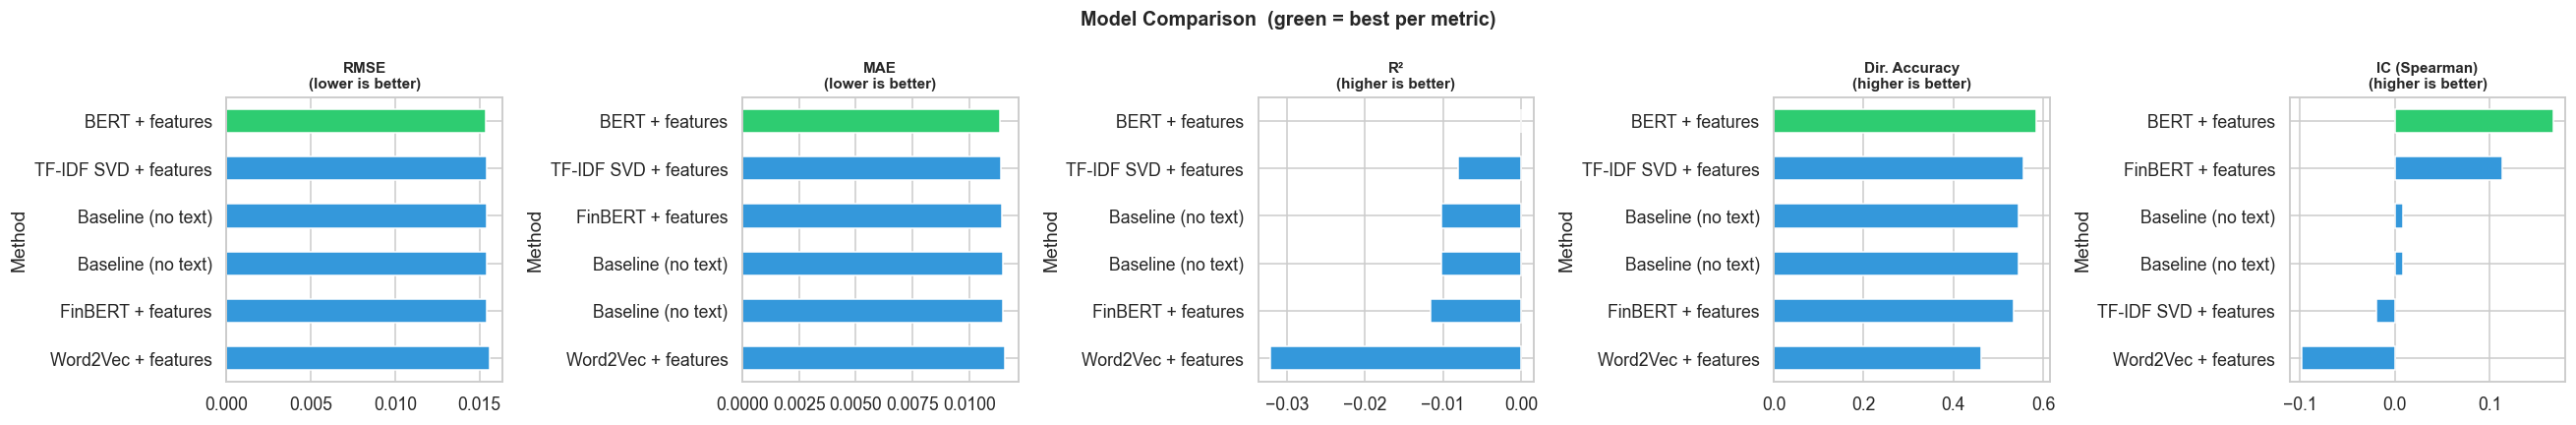


Best method by R²: BERT + features

Method                                     ΔR²    ΔDir.Acc       ΔIC
--------------------------------------------------------------------
BERT + features  Method
Baseline (no text)    0.010219
Baseline (no text)    0.010219
Name: R², dtype: float64  Method
Baseline (no text)    0.040963
Baseline (no text)    0.040963
Name: Dir. Accuracy, dtype: float64    Method
Baseline (no text)    0.158421
Baseline (no text)    0.158421
Name: IC (Spearman), dtype: float64
TF-IDF SVD + features  Method
Baseline (no text)    0.002124
Baseline (no text)    0.002124
Name: R², dtype: float64  Method
Baseline (no text)    0.011452
Baseline (no text)    0.011452
Name: Dir. Accuracy, dtype: float64    Method
Baseline (no text)   -0.027345
Baseline (no text)   -0.027345
Name: IC (Spearman), dtype: float64
FinBERT + features  Method
Baseline (no text)   -0.001429
Baseline (no text)   -0.001429
Name: R², dtype: float64  Method
Baseline (no text)   -0.010571
Baseline (no tex

In [48]:
# Metrics to display: (column name, ascending=True means lower is better)
METRIC_DISPLAY = [
    ('RMSE',           True),
    ('MAE',            True),
    ('R²',             False),
    ('Dir. Accuracy',  False),
    ('IC (Spearman)',  False),
]

fig, axes = plt.subplots(1, len(METRIC_DISPLAY), figsize=(24, 4))

for ax, (metric, ascending) in zip(axes, METRIC_DISPLAY):
    vals = results_df[metric].sort_values(ascending=ascending)
    best_val = vals.min() if ascending else vals.max()
    colors = ['#2ecc71' if v == best_val else '#3498db' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    direction = 'lower is better' if ascending else 'higher is better'
    ax.set_title(f'{metric}\n({direction})', fontweight='bold', fontsize=10)
    ax.invert_yaxis()

plt.suptitle('Model Comparison  (green = best per metric)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_method  = results_df['R²'].idxmax()
baseline_r2  = results_df.loc['Baseline (no text)', 'R²']
baseline_dir = results_df.loc['Baseline (no text)', 'Dir. Accuracy']
baseline_ic  = results_df.loc['Baseline (no text)', 'IC (Spearman)']

print(f'\nBest method by R²: {best_method}')
print(f'\n{"Method":<35}  {"ΔR²":>9}  {"ΔDir.Acc":>10}  {"ΔIC":>8}')
print('-' * 68)
for m in results_df.index:
    if m == 'Baseline (no text)':
        continue
    dr2  = results_df.loc[m, 'R²']            - baseline_r2
    ddir = results_df.loc[m, 'Dir. Accuracy'] - baseline_dir
    dic  = results_df.loc[m, 'IC (Spearman)'] - baseline_ic
    print(f'{m}  {dr2}  {ddir}    {dic}')

---
## Feature Importance — Best Model

### Text vs non-text split

In [49]:
best_model, best_feat_names, best_c2c = trained_models[best_method]

importances = best_model.get_feature_importance()
fi_df = (
    pd.DataFrame({'feature': best_feat_names, 'importance': importances})
    .assign(category=lambda x: x['feature'].map(best_c2c).fillna('other'))
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

text_imp = fi_df.loc[fi_df['category'] == 'text_embedding', 'importance'].sum()
meta_imp = fi_df.loc[fi_df['category'] != 'text_embedding', 'importance'].sum()
total    = text_imp + meta_imp

print(f'=== [{best_method}] Text vs Non-text Importance ===')
print(f'  Text embeddings : {text_imp:.2f}  ({100*text_imp/total:.1f}%)')
print(f'  Non-text features: {meta_imp:.2f}  ({100*meta_imp/total:.1f}%)')

=== [BERT + features] Text vs Non-text Importance ===
  Text embeddings : 1.47  (1.5%)
  Non-text features: 98.53  (98.5%)


### Importance by feature category

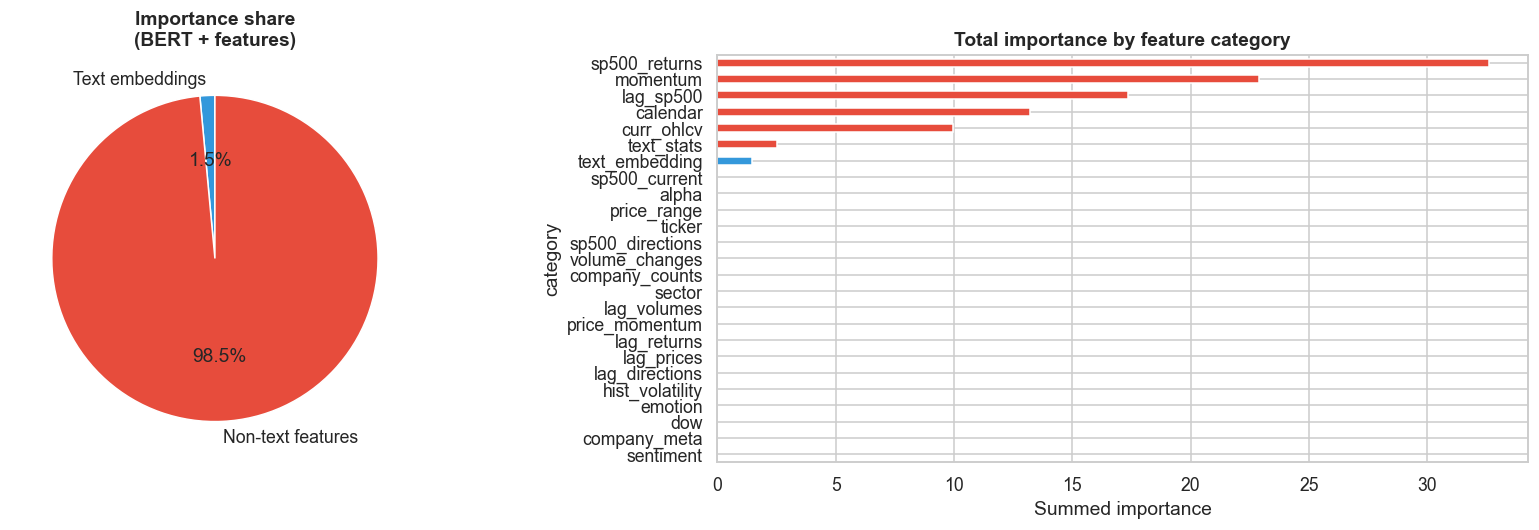


Category importance table (all non-text groups):
category
sp500_returns       32.627
momentum            22.874
lag_sp500           17.363
calendar            13.216
curr_ohlcv           9.945
text_stats           2.503
alpha                0.000
price_range          0.000
ticker               0.000
sp500_directions     0.000
sp500_current        0.000
sentiment            0.000
sector               0.000
lag_volumes          0.000
price_momentum       0.000
lag_returns          0.000
lag_prices           0.000
lag_directions       0.000
hist_volatility      0.000
emotion              0.000
dow                  0.000
company_meta         0.000
company_counts       0.000
volume_changes       0.000


In [50]:
cat_imp = (
    fi_df.groupby('category')['importance']
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── pie: text vs non-text ─────────────────────────────────────────────────────
axes[0].pie(
    [text_imp, meta_imp],
    labels=['Text embeddings', 'Non-text features'],
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90,
)
axes[0].set_title(f'Importance share\n({best_method})', fontweight='bold')

# ── bar: per category ─────────────────────────────────────────────────────────
colors_bar = ['#3498db' if c == 'text_embedding' else '#e74c3c'
              for c in cat_imp.index]
cat_imp.sort_values().plot(kind='barh', ax=axes[1], color=colors_bar[::-1],
                           edgecolor='white')
axes[1].set_title('Total importance by feature category', fontweight='bold')
axes[1].set_xlabel('Summed importance')

plt.tight_layout()
plt.show()

print('\nCategory importance table (all non-text groups):')
cat_imp_pct = (cat_imp / total * 100).round(3)
print(cat_imp_pct[cat_imp_pct.index != 'text_embedding'].to_string())

### Top-30 individual non-text features

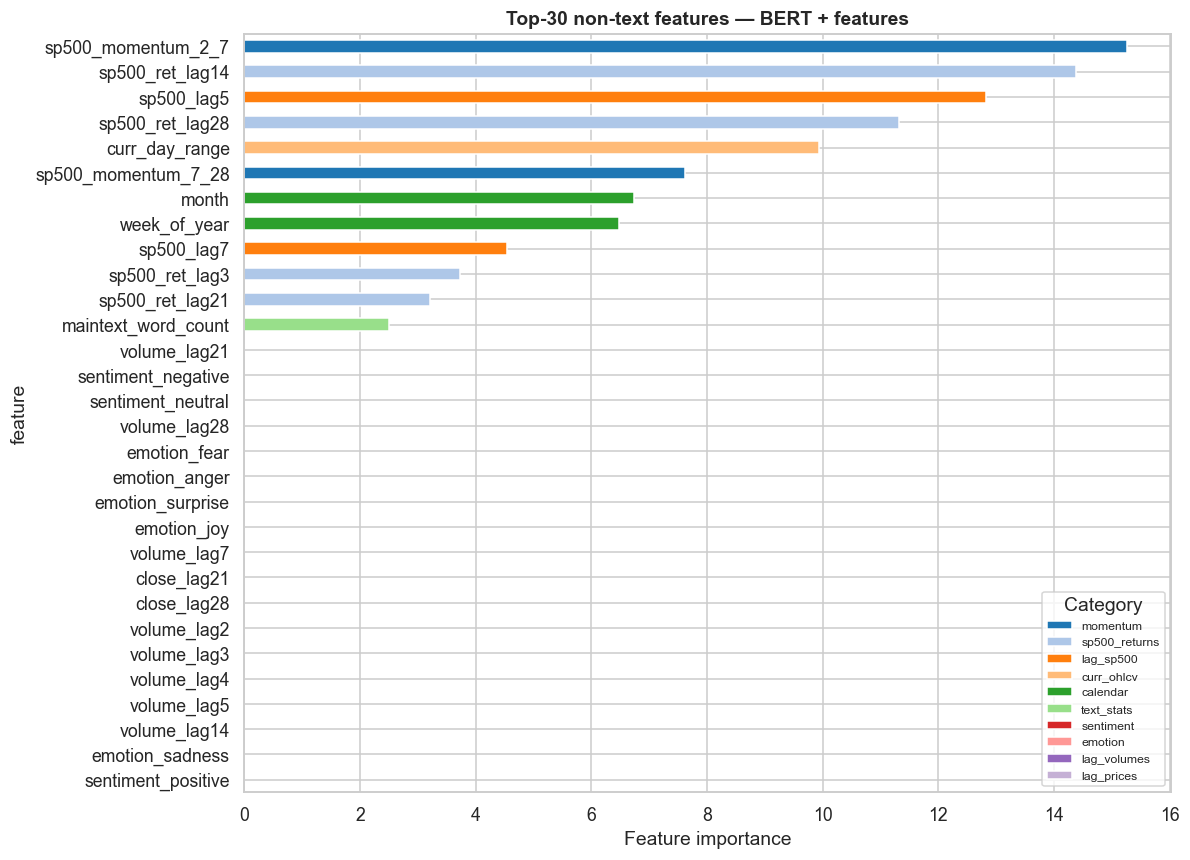

In [51]:
top_non_text = (
    fi_df[fi_df['category'] != 'text_embedding']
    .nlargest(30, 'importance')
    .set_index('feature')
)

# colour bars by category
palette = plt.cm.tab20.colors
unique_cats = list(top_non_text['category'].unique())
cat_color = {c: palette[i % len(palette)] for i, c in enumerate(unique_cats)}
bar_colors = [cat_color[c] for c in top_non_text['category']]

fig, ax = plt.subplots(figsize=(11, 8))
top_non_text['importance'].sort_values().plot(
    kind='barh', ax=ax, color=bar_colors[::-1], edgecolor='white'
)
ax.set_title(f'Top-30 non-text features — {best_method}', fontweight='bold')
ax.set_xlabel('Feature importance')

# legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_color[c], label=c) for c in unique_cats]
ax.legend(handles=legend_elements, title='Category',
          loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

### Baseline model — category importance (no text, cleaner signal)

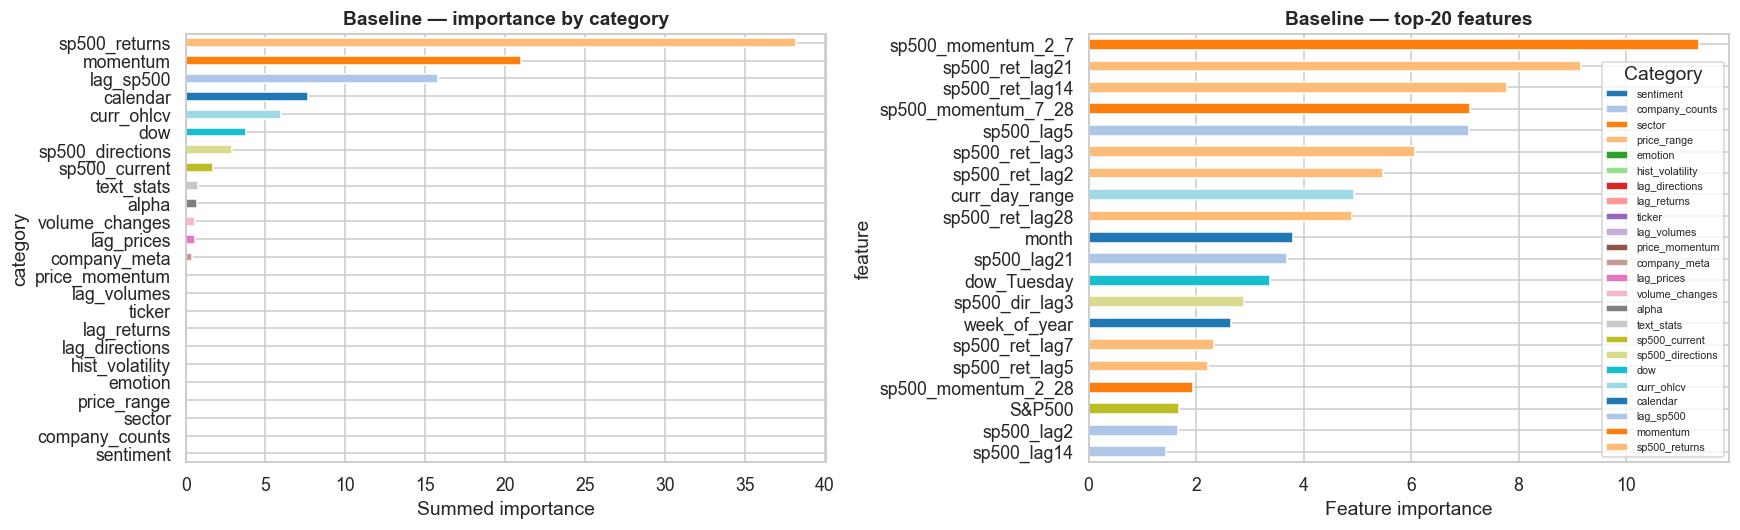


Baseline — category importance % (sorted):
category
sp500_returns       38.21
momentum            21.03
lag_sp500           15.79
calendar             7.65
curr_ohlcv           5.96
dow                  3.75
sp500_directions     2.89
sp500_current        1.69
text_stats           0.80
alpha                0.70
volume_changes       0.60
lag_prices           0.57
company_meta         0.37
company_counts       0.00
price_momentum       0.00
lag_volumes          0.00
ticker               0.00
lag_returns          0.00
lag_directions       0.00
hist_volatility      0.00
emotion              0.00
price_range          0.00
sector               0.00
sentiment            0.00


In [52]:
base_model, base_feat_names, base_c2c = trained_models['Baseline (no text)']
base_imp = base_model.get_feature_importance()

base_fi = (
    pd.DataFrame({'feature': base_feat_names, 'importance': base_imp})
    .assign(category=lambda x: x['feature'].map(base_c2c).fillna('other'))
)

base_cat_imp = (
    base_fi.groupby('category')['importance']
    .sum()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

palette = plt.cm.tab20.colors
all_cats  = list(base_cat_imp.index)
cat_colors_map = {c: palette[i % len(palette)] for i, c in enumerate(all_cats)}
bar_cols = [cat_colors_map[c] for c in base_cat_imp.index]

base_cat_imp.plot(kind='barh', ax=axes[0], color=bar_cols, edgecolor='white')
axes[0].set_title('Baseline — importance by category', fontweight='bold')
axes[0].set_xlabel('Summed importance')

# Top-20 individual baseline features
top_base = base_fi.nlargest(20, 'importance').set_index('feature')
top_bar_colors = [cat_colors_map.get(c, 'grey') for c in top_base['category']]
top_base['importance'].sort_values().plot(
    kind='barh', ax=axes[1], color=top_bar_colors[::-1], edgecolor='white'
)
axes[1].set_title('Baseline — top-20 features', fontweight='bold')
axes[1].set_xlabel('Feature importance')

legend_elements = [Patch(facecolor=cat_colors_map[c], label=c) for c in all_cats if c in cat_colors_map]
axes[1].legend(handles=legend_elements, title='Category', fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

print('\nBaseline — category importance % (sorted):')
total_base = base_imp.sum()
print((base_cat_imp.sort_values(ascending=False) / total_base * 100).round(2).to_string())

---
## Save Best Model

Save the best-performing model (selected by R²) and its metadata to disk.
The agent's `model_tool.py` will load `best_model.cbm` and `best_model_meta.json` once this cell has been run.

In [53]:
best_method = results_df['R²'].idxmax()
best_model, best_feat_names, best_c2c = trained_models[best_method]

MODEL_PATH = 'best_model.cbm'
META_PATH  = 'best_model_meta.json'

# ── CatBoost model ─────────────────────────────────────────────────────────────
best_model.save_model(MODEL_PATH)
print(f'Model saved  → {MODEL_PATH}')

# ── Text vectorizer (only needed for non-baseline methods) ────────────────────
# Maps the method display name to (text_method_key, variable_name, save_format)
_TEXT_METHOD_MAP = {
    'TF-IDF SVD + features': ('tf-idf-svd',  'tfidf_pipe',    'pkl'),
    'Word2Vec + features':   ('word2vec',     'w2v_model',     'bin'),
    'BERT + features':       ('bert',          None,           None),
    'FinBERT + features':    ('finbert',       None,           None),
}

text_method_key = None
if best_method in _TEXT_METHOD_MAP:
    text_method_key, var_name, fmt = _TEXT_METHOD_MAP[best_method]
    if var_name is not None:
        text_model_obj = locals().get(var_name) or globals().get(var_name)
        if text_model_obj is not None:
            if fmt == 'pkl':
                import pickle
                with open('best_text_model.pkl', 'wb') as _f:
                    pickle.dump(text_model_obj, _f)
                print('Text model saved → best_text_model.pkl')
            elif fmt == 'bin':
                text_model_obj.save('best_text_model.bin')
                print('Text model saved → best_text_model.bin')
    else:
        # BERT / FinBERT are loaded directly from HuggingFace — no file needed
        print(f'Text method {text_method_key!r}: pre-trained transformer, no file to save.')

# ── Metadata ───────────────────────────────────────────────────────────────────
best_metrics = results_df.loc[best_method].to_dict()
meta = {
    'best_method':   best_method,
    'text_method':   text_method_key,   # None for baseline; used by agent/model_tool.py
    'text_col':      TEXT_COL,
    'target':        TARGET,
    'split': {
        'train': int(len(idx_train)),
        'val':   int(len(idx_val)),
        'test':  int(len(idx_test)),
        'train_end_date': str(train_end_date)[:10],
        'val_end_date':   str(val_end_date)[:10],
    },
    'feature_names': best_feat_names,
    'metrics':       {k: round(float(v), 6) for k, v in best_metrics.items()},
}

with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved → {META_PATH}')

print(f'\n=== Saved model summary ===')
print(f'  Method      : {best_method}')
print(f'  Text method : {text_method_key}')
print(f'  Text column : {TEXT_COL}')
print(f'  Features    : {len(best_feat_names)}')
for k, v in best_metrics.items():
    print(f'  {k:<18}: {v:.6f}')

Model saved  → best_model.cbm
Text method 'bert': pre-trained transformer, no file to save.
Metadata saved → best_model_meta.json

=== Saved model summary ===
  Method      : BERT + features
  Text method : bert
  Text column : maintext
  Features    : 571
  RMSE              : 0.015337
  MAE               : 0.011345
  Median AE         : 0.008901
  Max Error         : 0.064829
  R²                : 0.000060
  Expl. Var.        : 0.007729
  Dir. Accuracy     : 0.585523
  IC (Spearman)     : 0.166912


In [54]:
print('aaaaa')

aaaaa
